In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('..')

from pathlib import Path
from pynwb import NWBHDF5IO
from gaussian_filtering import fit_gaussian_to_rf, get_rf_size_degrees

## Inspect NWB file

In [3]:
nwb_path = r"X:\Personnel\MaryBeth\OpenScope\001568\sub-817335\sub-817335_ses-ecephys-817335-2025-08-27-14-46-51_ecephys.nwb"

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Ignoring cached namespace")
    io = NWBHDF5IO(nwb_path, "r", load_namespaces=True)
    nwb = io.read()

# Inspect RF stimulus table
rf_stim_table = nwb.intervals["receptive_field_block_presentations"].to_dataframe()

xs = np.sort(rf_stim_table.x_position.astype(float).unique())
ys = np.sort(rf_stim_table.y_position.astype(float).unique())

print(f"X positions: {xs}")
print(f"Y positions: {ys}")
print(f"Presentations per location: {rf_stim_table.groupby(['x_position','y_position']).size().unique()}")
print(f"Stim duration: {(rf_stim_table.stop_time - rf_stim_table.start_time).mean():.3f} s")
print(f"Number of units: {len(nwb.units.id[:])}")
print(f"Units columns: {list(nwb.units.to_dataframe().columns)}")

X positions: [-40. -30. -20. -10.   0.  10.  20.  30.  40.]
Y positions: [-40. -30. -20. -10.   0.  10.  20.  30.  40.]
Presentations per location: [60]
Stim duration: 0.250 s
Number of units: 2403
Units columns: ['spike_times', 'electrodes', 'waveform_mean', 'waveform_sd', 'unit_name', 'drift_ptp', 'decoder_label', 'nn_hit_rate', 'snr', 'depth', 'repolarization_slope', 'firing_rate', 'rp_contamination', 'd_prime', 'amplitude_cv_median', 'amplitude_cutoff', 'shank', 'l_ratio', 'drift_mad', 'nn_miss_rate', 'num_negative_peaks', 'amplitude', 'sliding_rp_violation', 'estimated_z', 'default_qc', 'original_cluster_id', 'drift_std', 'presence_ratio', 'peak_to_valley', 'extremum_channel_index', 'num_spikes', 'velocity_above', 'decoder_probability', 'recovery_slope', 'peak_trough_ratio', 'firing_range', 'isolation_distance', 'amplitude_median', 'half_width', 'isi_violations_ratio', 'silhouette', 'sync_spike_8', 'exp_decay', 'ks_unit_id', 'spread', 'amplitude_cv_range', 'estimated_y', 'estimate

In [4]:
print(rf_stim_table) 

       start_time    stop_time              stim_name    stim_type stim_block  \
id                                                                              
0       42.763471    43.013681  receptive_field_block  GratingStim        0.0   
1       43.013681    43.263890  receptive_field_block  GratingStim        0.0   
2       43.263890    43.514100  receptive_field_block  GratingStim        0.0   
3       43.514100    43.764309  receptive_field_block  GratingStim        0.0   
4       43.764309    44.014517  receptive_field_block  GratingStim        0.0   
...           ...          ...                    ...          ...        ...   
4855  1257.581353  1257.831561  receptive_field_block  GratingStim        0.0   
4856  1257.831561  1258.081771  receptive_field_block  GratingStim        0.0   
4857  1258.081771  1258.331980  receptive_field_block  GratingStim        0.0   
4858  1258.331980  1258.582190  receptive_field_block  GratingStim        0.0   
4859  1258.582190  1258.8323

## Write functions to build the receptive field and calcualte its center

In [5]:
def get_unit_probe(unit_idx, units):
    """Get the probe/device name for a unit."""
    return str(units['device_name'][unit_idx])


def select_condition(unit_idx, units, probe, all_units=False):
    """Return True if unit is on the given probe and passes SNR > 1 (unless all_units=True)."""
    if all_units:
        return get_unit_probe(unit_idx, units) == probe
    return (units['snr'][unit_idx] > 1 and
            get_unit_probe(unit_idx, units) == probe)


def get_rf(spike_times, xs, ys, rf_stim_table):
    """
    Calculate receptive field from spike times and stimulus presentations.
    Returns a 2D array (ys x xs) of spike counts in the 0–200ms window after each stimulus.
    """
    unit_rf = np.zeros([ys.size, xs.size])

    for xi, x in enumerate(xs):
        for yi, y in enumerate(ys):
            stim_times = rf_stim_table[
                (rf_stim_table.x_position == str(x)) &
                (rf_stim_table.y_position == str(y))
            ].start_time

            response_spike_count = 0
            for stim_time in stim_times:
                start_idx, end_idx = np.searchsorted(
                    spike_times,
                    [stim_time, stim_time + 0.2]
                )
                response_spike_count += end_idx - start_idx

            unit_rf[yi, xi] = response_spike_count

    return unit_rf

## Test on single unit

Probe ProbeA: 509 units passing SNR filter
Unit 389: center=(-40.0, -11.4) deg,  R²=0.873


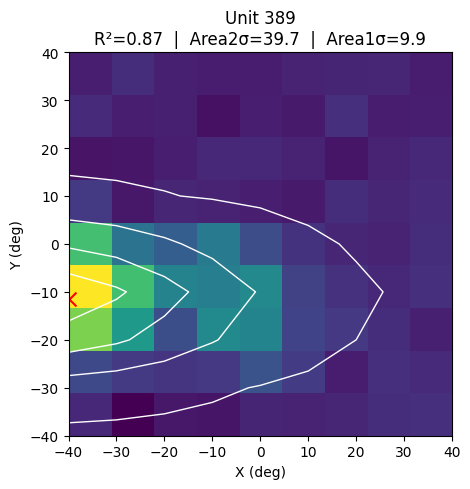

In [7]:
probe = sorted(set(nwb.units['device_name'][:]))[0]

unit_indices = []
unit_rfs     = []
for unit_idx in range(len(nwb.units)):
    if select_condition(unit_idx, nwb.units, probe):
        unit_indices.append(unit_idx)
        spike_times = nwb.units['spike_times'][unit_idx]
        unit_rfs.append(get_rf(spike_times, xs, ys, rf_stim_table))

print(f"Probe {probe}: {len(unit_indices)} units passing SNR filter")

# Plot a random good-fitting unit
random_idx = np.random.randint(0, len(unit_rfs))
rf = unit_rfs[random_idx]
popt, r_squared, fitted_rf = fit_gaussian_to_rf(rf)

if popt is not None:
    x_center = float(np.interp(popt[1], np.arange(len(xs)), xs))
    y_center = float(np.interp(popt[2], np.arange(len(ys)), ys))
    area_2sigma = np.pi * (2 * popt[3]) * (2 * popt[4])
    area_1sigma = np.pi * popt[3] * popt[4]
    print(f"Unit {unit_indices[random_idx]}: center=({x_center:.1f}, {y_center:.1f}) deg,  R²={r_squared:.3f}")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(rf, origin='lower', cmap='viridis',
              extent=(xs.min(), xs.max(), ys.min(), ys.max()))
    ax.contour(fitted_rf, levels=3, colors='white', linewidths=1,
               extent=(xs.min(), xs.max(), ys.min(), ys.max()))
    ax.scatter(x_center, y_center, color='red', marker='x', s=100)
    ax.set_xlabel('X (deg)')
    ax.set_ylabel('Y (deg)')
    ax.set_title(f"Unit {unit_indices[random_idx]}\nR²={r_squared:.2f}  |  Area2σ={area_2sigma:.1f}  |  Area1σ={area_1sigma:.1f}")
    plt.tight_layout()
    plt.show()
else:
    print(f"Unit {unit_indices[random_idx]}: fit failed")


In [8]:
print(spike_times.min(), spike_times.max())
print(rf_stim_table.start_time.min(), rf_stim_table.start_time.max())

56.347402161012425 5412.71908923954
42.76347106036143 1258.582189514707


## Build RFs for all mice

In [ ]:
data_dir   = Path(r"X:\Personnel\MaryBeth\OpenScope\001568")
output_dir = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ephys\results")
output_dir.mkdir(exist_ok=True)

mouse_dirs = [d for d in data_dir.iterdir() if d.is_dir() and d.name.startswith('sub-')]
print(f"Found {len(mouse_dirs)} mouse directories")

In [ ]:
R2_THRESHOLD = 0.5

unit_records_all = []

for mouse_idx, mouse_dir in enumerate(mouse_dirs, 1):
    mouse_name = mouse_dir.name
    print("=" * 80)
    print(f"Processing Mouse {mouse_idx}/{len(mouse_dirs)}: {mouse_name}")
    print("=" * 80)

    nwb_files = list(mouse_dir.glob("*.nwb"))
    if not nwb_files:
        print(f"  No NWB files found, skipping.")
        continue

    io = None
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="Ignoring cached namespace")
            io = NWBHDF5IO(str(nwb_files[0]), "r", load_namespaces=True)
            nwb = io.read()

        nwb_data = {
            'nwb':           nwb,
            'units':         nwb.units,
            'rf_stim_table': nwb.intervals["receptive_field_block_presentations"].to_dataframe(),
        }

        units         = nwb_data['units']
        rf_stim_table = nwb_data['rf_stim_table']

        xs = np.sort([float(x) for x in set(rf_stim_table.x_position)])
        ys = np.sort([float(y) for y in set(rf_stim_table.y_position)])

        probes = sorted(set(units['device_name'][:]))
        print(f"  Probes: {probes}")

        for probe in probes:
            print(f"  --- Probe: {probe} ---")

            rf_save_dir   = output_dir / "rf_maps"   / mouse_name / probe
            rf_images_dir = output_dir / "rf_images" / mouse_name / probe
            rf_save_dir.mkdir(parents=True, exist_ok=True)

            # All units on this probe — no SNR filter
            unit_indices = []
            unit_rfs     = []

            for unit_idx in range(len(units)):
                if select_condition(unit_idx, units, probe, all_units=True):
                    unit_indices.append(unit_idx)
                    spike_times = nwb.units['spike_times'][unit_idx]
                    unit_rfs.append(get_rf(spike_times, xs, ys, rf_stim_table))

            print(f"    Units: {len(unit_indices)}")

            for idx, (unit_idx, rf) in enumerate(zip(unit_indices, unit_rfs)):
                namespaced_id = f"{mouse_name}__{probe}__unit{unit_idx}"

                # Single fit call — extract everything
                popt, r_squared, fitted_rf = fit_gaussian_to_rf(rf)

                if popt is not None:
                    x_center = float(np.interp(popt[1], np.arange(len(xs)), xs))
                    y_center = float(np.interp(popt[2], np.arange(len(ys)), ys))

                    area_2sigma = np.pi * (2 * popt[3]) * (2 * popt[4])
                    area_1sigma = np.pi * popt[3] * popt[4]

                    size_metrics   = get_rf_size_degrees(popt, rf.shape)
                    rf_fwhm        = size_metrics['fwhm_degrees']
                    rf_size_deg    = size_metrics['size_degrees']
                    rf_sigma_x_deg = size_metrics['sigma_x_degrees']
                    rf_sigma_y_deg = size_metrics['sigma_y_degrees']
                    fit_status     = 'success'
                else:
                    x_center = y_center = np.nan
                    r_squared = np.nan
                    area_2sigma = area_1sigma = np.nan
                    rf_fwhm = rf_size_deg = rf_sigma_x_deg = rf_sigma_y_deg = np.nan
                    fit_status = 'failed'

                # Save RF data bundle
                np.savez(
                    rf_save_dir / f"unit{unit_idx}_rf.npz",
                    rf=rf,
                    fitted_rf=fitted_rf if fitted_rf is not None else np.full_like(rf, np.nan),
                    xs=xs,
                    ys=ys,
                    popt=np.array(popt) if popt is not None else np.full(7, np.nan),
                    unit_id=np.array(namespaced_id),
                    raw_unit_id=np.array(unit_idx),
                    mouse_name=np.array(mouse_name),
                    probe=np.array(probe),
                    rf_center_x=np.array(x_center),
                    rf_center_y=np.array(y_center),
                    r_squared=np.array(r_squared if not np.isnan(r_squared) else np.nan),
                )

                # Save image only for well-fitted RFs — raw RF with Gaussian contour overlaid
                if not np.isnan(r_squared) and r_squared >= R2_THRESHOLD:
                    rf_images_dir.mkdir(parents=True, exist_ok=True)
                    fig, ax = plt.subplots(figsize=(5, 5))
                    im = ax.imshow(rf, origin='lower', cmap='viridis',
                                   extent=(xs.min(), xs.max(), ys.min(), ys.max()))
                    plt.colorbar(im, ax=ax, label='spike count')
                    ax.contour(fitted_rf, levels=3, colors='white', linewidths=1,
                               extent=(xs.min(), xs.max(), ys.min(), ys.max()))
                    ax.scatter(x_center, y_center, color='red', marker='x', s=100)
                    ax.set_xlabel('X (deg)')
                    ax.set_ylabel('Y (deg)')
                    ax.set_title(f"{namespaced_id}\nR²={r_squared:.2f}", fontsize=10)
                    plt.tight_layout()
                    fig.savefig(rf_images_dir / f"unit{unit_idx}_rf.png", dpi=150, bbox_inches='tight')
                    plt.close(fig)

                unit_records_all.append({
                    'unit_id':         namespaced_id,
                    'raw_unit_id':     unit_idx,
                    'mouse_name':      mouse_name,
                    'probe':           probe,
                    'snr':             float(units['snr'][unit_idx]),
                    'rf_center_x':     x_center,
                    'rf_center_y':     y_center,
                    'rf_r_squared':    r_squared,
                    'max_response':    float(rf.max()),
                    'fit_status':      fit_status,
                    'area_2sigma':     area_2sigma,
                    'area_1sigma':     area_1sigma,
                    'rf_fwhm_deg':     rf_fwhm,
                    'rf_size_deg':     rf_size_deg,
                    'rf_sigma_x_deg':  rf_sigma_x_deg,
                    'rf_sigma_y_deg':  rf_sigma_y_deg,
                    'rf_map_path':     str(rf_save_dir / f"unit{unit_idx}_rf.npz"),
                })

    except Exception as e:
        import traceback
        print(f"  ERROR on {mouse_name}: {e}")
        traceback.print_exc()

    finally:
        if io is not None:
            io.close()
            print(f"  NWB file closed for {mouse_name}")

# Save summary CSV
units_df_out = pd.DataFrame(unit_records_all)
units_df_out.to_csv(output_dir / "ephys_rf_unit_info.csv", index=False)

n_good = (units_df_out['rf_r_squared'] >= R2_THRESHOLD).sum()
print(f"\nDone. {len(units_df_out)} total units, {n_good} with R² >= {R2_THRESHOLD} saved as images.")
print(units_df_out.head())